# Prueba Ji Cuadrada: La primera prueba de bondad de ajuste

Durante el siglo XIX, mientras Pearson realizaba estudios sobre la herencia genética y las leyes de Mendel, surgió la necesidad de una herramienta estadística para evaluar el ajuste de los datos a un modelo teórico. Fue así como se desarrolló la prueba Ji Cuadrada, el primer método de bondad de ajuste formalmente reconocido.

Como toda prueba de bondad de ajuste, se busca comparar los datos observados contra los datos que se esperarían observar bajo una distribución teórica específica, y si difieren por mucho, hay evidencia en contra de que los datos sigan esa distribución. 

Esta prueba se basa en comparar las frecuencias observadas contra las frecuencias esperadas. Esto quiere decir que se asume un espacio de categorías o clases (mutuamente excluyentes y exhaustivas) y se cuenta cuántos datos caen en cada categoría (frecuencias observadas) y se calcula cuántos datos se esperarían en cada categoría bajo la distribución teórica (frecuencias esperadas). Este proceso puede generar pérdida de información pues se agrupan los datos en las categorías. 

Para un mejor uso de la prueba, se recomienda utilizar en variables categóricas o discretas, porque aplicar a variables continuas puede generar conclusiones erróneas debido a la pérdida de información al agrupar los datos en categorías.

## Formulación de la hipótesis

La prueba Ji Cuadrada se puede formular de dos formas:  

### Especificando la distribución teórica
$$
H_0: X \sim D(\theta)  \qquad H_1: X \not\sim D(\theta)
$$

En este escenario, las categorías no están dadas previamente, y se asignan de forma arbitaria. Algunos autores sugieren que se asignen de forma equitativa, es decir, con la misma cantidad de datos en cada categoría. Sin embargo, esto no es necesario, y se pueden asignar las categorías de acuerdo a criterios específicos del problema.



### Especificando las probabilidades de cada categoría
$$
H_0: p_i = \pi_i, \quad i = 1, 2, \ldots, k \qquad H_1: \text{al menos una } p_i \neq \pi_i
$$

Condiciones:

- $\sum_{i=1}^{k} \pi_i = 1 $
- $\sum_{i=1}^{k} e_i = n = \sum_{i=1}^{k} O_i$ pero no necesariamente $e_i = O_i$ para cada $i$.


En este caso, las categorías están dadas previamente, por lo que no hay pérdida de información al asignar los datos a las categorías. Sin embargo, es necesario especificar las probabilidades de cada categoría bajo la hipótesis nula, lo cual puede ser difícil en algunos casos.

## Procedimiento

1. Definir las categorías o clases $(C_i)$ en las que se agruparán los datos.
2. Contar las frecuencias observadas $(O_i)$ en cada categoría.
3. Calcular las probabilidades inducidas por $H_0$ para cada categoría. 

$$
\pi_i = P(X \in C_{i} | H_0) = P(X \in C_{i} | X \sim D(\theta))
$$

3. Calcular las frecuencias esperadas $(e_i = n \pi_i)$ bajo $H_0$
4. Calcular el estadístico de prueba:
   $$
   \sum_{i=1}^{k} \frac{(O_i - e_i)^2}{e_i} \quad \sim \chi^2_{k-1}
   $$
   donde $k$ es el número de categorías.

5. Calcular el cuantil de orden $1 - \alpha$ de la distribución $\chi^2$ con $k-1$ grados de libertad

6. Hay evidencia en contra de $H_0$ si el estadístico de prueba es mayor que el cuantil calculado en el paso anterior, o si el p-value es menor que $\alpha$.

## Limitaciones

- Conclusiones erróneas al aplicar a variables continuas debido a la pérdida de información al agrupar los datos en categorías.
- Requiere un tamaño de muestra $n \geq 20 $ 
- Cada categoría debe tener una frecuencia observada de al menos $5$ (si no, se pueden agrupar categorías para cumplir esta condición).

## Ejemplo variable continua

Para ilustrar la aplicación de la prueba Ji Cuadrada a una variable continua, consideremos el siguiente ejemplo:



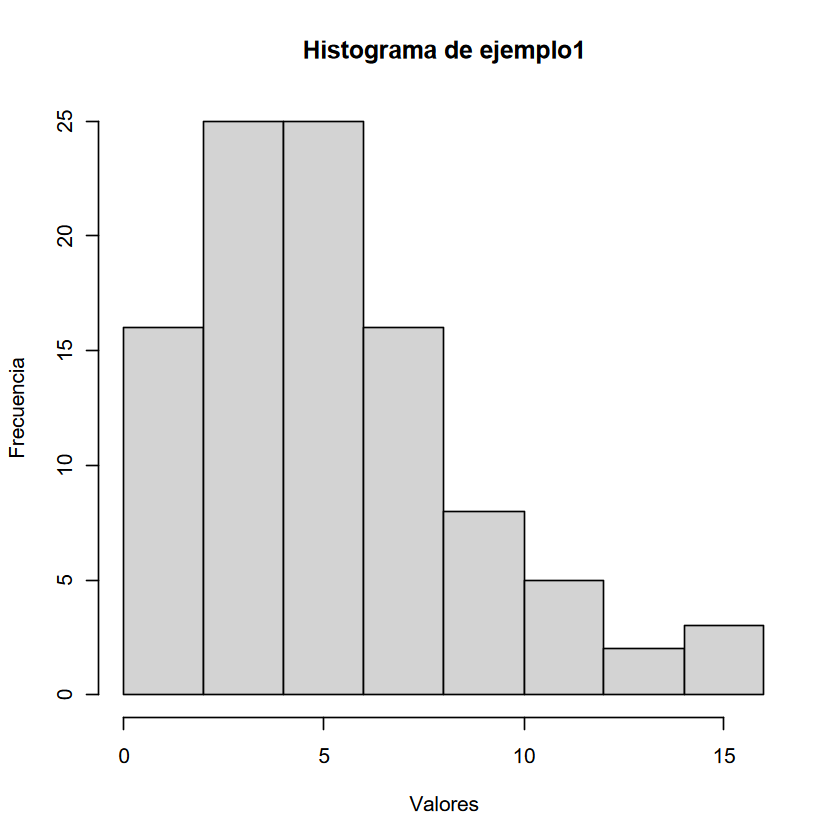

In [45]:
set.seed(123)

ejemplo1<- rgamma(100, shape = 2, scale = 3)
hist(ejemplo1, breaks = 10, main = "Histograma de ejemplo1", xlab = "Valores", ylab = "Frecuencia")






In [46]:
library(fitdistrplus)

modelo_gamma <- fitdist(ejemplo1, "gamma")
summary(modelo_gamma)

modelo_exp <- fitdist(ejemplo1, "exp")
summary(modelo_exp)



Fitting of the distribution ' gamma ' by maximum likelihood 
Parameters : 
       estimate Std. Error
shape 2.1928550 0.28963050
rate  0.4245613 0.06297949
Loglikelihood:  -249.8111   AIC:  503.6222   BIC:  508.8325 
Correlation matrix:
          shape      rate
shape 1.0000000 0.8903723
rate  0.8903723 1.0000000


Fitting of the distribution ' exp ' by maximum likelihood 
Parameters : 
      estimate Std. Error
rate 0.1936296 0.01936245
Loglikelihood:  -264.1808   AIC:  530.3616   BIC:  532.9668 

$ H_0: X \sim Exp(\lambda_{MV})  \quad H_1: X \not\sim Exp(\lambda_{MV})$

In [47]:
# x vector de datos
# p probabilidades
# rescale.p para que sume 1 las prbas

chisq.test(x = ejemplo1,p = dexp(ejemplo1, rate = modelo_exp$estimate),rescale.p = TRUE)
 


Warning message in chisq.test(x = ejemplo1, p = dexp(ejemplo1, rate = modelo_exp$estimate), :
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  ejemplo1
X-squared = 2009.2, df = 99, p-value < 2.2e-16


Rechaza la distribución verdadera.

In [48]:
chisq.test(x = ejemplo1,p = dgamma(ejemplo1, shape= modelo_gamma$estimate[1],rate = modelo_gamma$estimate[2]),rescale.p = TRUE )

Warning message in chisq.test(x = ejemplo1, p = dgamma(ejemplo1, shape = modelo_gamma$estimate[1], :
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  ejemplo1
X-squared = 3378, df = 99, p-value < 2.2e-16


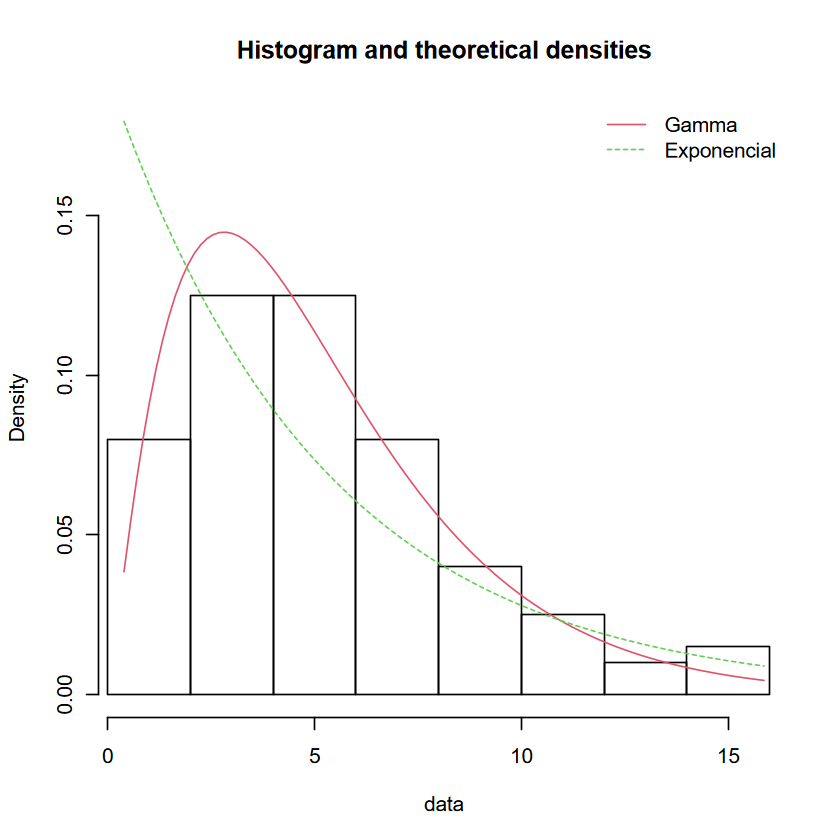

In [49]:
denscomp(list(modelo_gamma, modelo_exp), legendtext = c("Gamma", "Exponencial"))


## Ejemplo: Satisfacción del sevicio hospitalario en CDMX

En los hospitales de la CDMX se desea evaluar la calidad del servicio hospitalario, expertos sugieren que basta con preguntar acerca del grado de satisfacción de los pacientes con respecto al sevicio de los doctores. 


Este estudio permitirá identificar la situación actual del servicio en CDMX, para que posteriormente se implementen medidas para mejorar el servicio.



Se pregunta a los pacientes ¿Qué tan satisfecho está con el servicio del doctor? Las posibles respuestas son: 

1. Insatisfecho con el servicio.
2. Conforme con el servicio.
3. Muy agradecido con el servicio. 


Para asignar una evaluación a cada hospital, se consideran 3 tipos de hospitales:

- Hospital con mal servicio: 50% insatisfecho con el servicio, 30 % conforme y 20% muy agradecido.

- Hospital con servicio regular: 35% insatisfecho con el servicio, 45 % conforme y 20% muy agradecido.

- Hospital con excelente servicio: 20% insatisfecho con el servicio, 45 % conforme y 35% muy agradecido.


Se tiene las respuestas de pacientes de 3 clinicas clave en la CDMX. Sucursal Centro, Sucursal Norte y Sucursal Sur, y se desea verificar el tipo de hospital que son.



